In [10]:
%load_ext autoreload
%autoreload 2

import site
import sys

site.addsitedir('/Users/fabien/Documents/workspace/github/policosm')  # Always appends to end
print(sys.path)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
['/Users/fabien/Documents/workspace/github/policosm', '/Users/fabien/Documents/workspace/github/policosm', '/Users/fabien/Documents/workspace/github/policosm', '/Users/fabien/Documents/workspace/github/policosm', '/Users/fabien/workspace/github/policosm', '/Users/fabien/workspace/github/policosm', '/Users/fabien/workspace/github/policosm', '/Users/fabien/workspace/github/policosm', '/Users/fabien/workspace/github/policosm', '/Users/fabien/Documents/workspace/github/policosm', '/Users/fabien/Documents/workspace/github/policosm/examples/notebooks', '/Users/fabien/.pyenv/versions/3.8.6/lib/python38.zip', '/Users/fabien/.pyenv/versions/3.8.6/lib/python3.8', '/Users/fabien/.pyenv/versions/3.8.6/lib/python3.8/lib-dynload', '', '/Users/fabien/.pyenv/versions/3.8.6/lib/python3.8/site-packages', '/Users/fabien/.pyenv/versions/3.8.6/lib/python3.8/site-packages/IPython/extensions', '/Users/fabien/.ipython', '/

In [11]:
import policosm

In [12]:
import geopandas as gpd
import pandas as pd
import geopandas as gpd
import geoparquet as gpq
import graph_tool as gt
import seaborn as sns
import numpy as np
from shapely.geometry import Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from more_itertools import pairwise
from matplotlib import pyplot
sns.set()
%matplotlib inline

In [7]:
roads = policosm.classes.roads.Roads(directed=False, country_iso3="chn")
roads.apply_file('/Volumes/Download/10-Fabien-Data/shanghai.pbf', locations=True)

In [8]:
roads.osm_to_dataframes(project_to_meters=True,project_overwrite_epsg=4576)

In [13]:
roads.processing_simplify()

In [14]:
roads.dfe.to_parquet('/Users/fabien/Documents/workspace/SHU-communities/data/shanghai-roads-simplified.parquet')

<ipython-input-14-34afa8e8d540>:1: UserWarning: this is an initial implementation of Parquet/Feather file support and associated metadata.  This is tracking version 0.1.0 of the metadata specification at https://github.com/geopandas/geo-arrow-spec

This metadata specification does not yet make stability promises.  We do not yet recommend using this in a production setting unless you are able to rewrite your Parquet/Feather files.

To further ignore this warning, you can do: 
import warnings; warnings.filterwarnings('ignore', message='.*initial implementation of Parquet.*')
  roads.dfe.to_parquet('/Users/fabien/Documents/workspace/SHU-communities/data/shanghai-roads-simplified.parquet')


In [5]:
dfe = pd.read_pickle('/Users/fabien/Documents/workspace/shanghai-4479.pkl')

In [8]:
dfe.head(n=2)

,u,v,osm_id,highway,level,lanes,width,bicycle,bicycle_safety,foot,foot_safety,max_speed,motorcar,geometry
edge_id,,,,,,,,,,,,,,
0,115443169,1930275790,8621489,residential,3,1,3.0,1,2,1,1,-1,1,"LINESTRING (21362422.312 3461130.524, 21362506..."
1,1930275790,115443169,8621489,residential,3,1,3.0,1,2,1,1,-1,1,"LINESTRING (21362506.500 3460980.047, 21362422..."


In [9]:
gdf = gpd.GeoDataFrame(dfe, geometry='geometry', crs=4576)
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Int64Index: 316626 entries, 0 to 1132597
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   u               316626 non-null  int64   
 1   v               316626 non-null  int64   
 2   osm_id          316626 non-null  object  
 3   highway         316626 non-null  object  
 4   level           316626 non-null  int64   
 5   lanes           316626 non-null  int64   
 6   width           316626 non-null  float64 
 7   bicycle         316626 non-null  int64   
 8   bicycle_safety  316626 non-null  int64   
 9   foot            316626 non-null  int64   
 10  foot_safety     316626 non-null  int64   
 11  max_speed       316626 non-null  int64   
 12  motorcar        316626 non-null  int64   
 13  geometry        316626 non-null  geometry
dtypes: float64(1), geometry(1), int64(10), object(2)
memory usage: 36.2+ MB


In [10]:
gdf['length_m'] = gdf.geometry.length

In [11]:
gdf['bicycle_time'] = gdf.geometry.length / 3.05

In [12]:
gdf['foot_time'] = gdf.geometry.length / 1.33

In [13]:
gdf['car_time'] = gdf.geometry.length / 8.3

In [14]:
gdf.dropna(inplace=True)
len(gdf)

316626

In [328]:
gdf.bicycle.unique()

array([1, 0])

In [15]:
gdf_car = gdf[gdf['level']>=3].copy(deep=True)
gdf_foot = gdf[gdf['foot']>0].copy(deep=True)
gdf_bike = gdf[gdf['bicycle']>0].copy(deep=True)

In [16]:
import itertools
from operator import itemgetter

import geopandas as gpd
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

from scipy.spatial import cKDTree
from shapely.geometry import Point, LineString

In [372]:
list(enumerate(list(map(len, gdf_foot))))

[(0, 1),
 (1, 1),
 (2, 6),
 (3, 7),
 (4, 5),
 (5, 5),
 (6, 5),
 (7, 7),
 (8, 14),
 (9, 4),
 (10, 11),
 (11, 9),
 (12, 8),
 (13, 8),
 (14, 8),
 (15, 12),
 (16, 9),
 (17, 11),
 (18, 11),
 (19, 8)]

In [62]:
df = pd.read_excel('/Users/fabien/Documents/workspace/SHU-communities/data/Shanghai_Community_XY.xls',names=['name','town','district','code','temp_lon','temp_lat'])
gpd2 = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.temp_lon, df.temp_lat), crs=4326)
#print(gpd2.crs)
#gpd2 = gdf.set_crs(4326)
gpd2 = gpd2.to_crs(4576)

In [332]:
gpd1 = gpd.GeoDataFrame([['CCIFC', Point(21351908, 3456756)]], columns=['Name', 'geometry'])


def ckdnearest(gdfA, gdfB, gdfB_cols=['g']):
    A = np.concatenate([np.array(geom.coords) for geom in gdfA.geometry.to_list()])
    B = [np.array(geom.coords) for geom in gdfB.geometry.to_list()]
    B_ix = tuple(itertools.chain.from_iterable([itertools.repeat(i, x) for i, x in enumerate(list(map(len, B)))]))
    B = np.concatenate(B)
    ckd_tree = cKDTree(B)
    dist, idx = ckd_tree.query(A, k=1)
    idx = itemgetter(*idx)(B_ix)
    return idx, dist

idx_car, dist = ckdnearest(gpd1, gdf_car)
idx_bike, dist = ckdnearest(gpd1, gdf_bike)
idx_foot, dist = ckdnearest(gpd1, gdf_foot)

In [73]:
#gpd1 = gpd.GeoDataFrame([['CCIFC', Point(21351908, 3456756)]], columns=['Name', 'geometry'])


B = [np.array(geom.coords) for geom in gdf_bike.geometry.to_list()]
B_ix = tuple(itertools.chain.from_iterable([itertools.repeat(i, x) for i, x in enumerate(list(map(len, B)))]))
B = np.concatenate(B)
ckd_tree = cKDTree(B)

def ckdnearest(gdfA, gdfB, gdfB_cols=['g']):
    A = np.concatenate([np.array(geom.coords) for geom in gdfA.geometry.to_list()])
    dist, idx = ckd_tree.query(A, k=1)
    idx = itemgetter(*idx)(B_ix)
    return gdf_bike.iloc[idx].name

#idx_car, dist = ckdnearest(gpd1, gdf_car)
#idx_bike, dist = ckdnearest(gpd1, gdf_bike)
#idx_foot, dist = ckdnearest(gpd1, gdf_foot)
edge_ids_communities = []
for row in gpd2[['name','geometry']].iterrows():
    name = ckdnearest(gpd.GeoDataFrame(row[1:], columns=['name', 'geometry']), gdf_bike)
    edge_ids_communities.append(name)
gpd2['nearest'] = edge_ids_communities


In [74]:
gpd2.nearest

0       1015140
1        994788
2         92242
3        985582
4         38181
         ...   
5854    1101661
5855    1096903
5856    1130349
5857     985416
5858    1063330
Name: nearest, Length: 5859, dtype: int64

In [333]:
edge_id_car = gdf_car.iloc[idx_car].name
edge_id_bike = gdf_bike.iloc[idx_bike].name
edge_id_foot = gdf_foot.iloc[idx_foot].name
#gdf_foot.iloc[idx]

In [348]:
g = gt.Graph(directed=True)
time = g.new_edge_property('float')
edges_id = g.new_edge_property('int')

edgelist = gdf_foot.reset_index()[['u','v','foot_time', 'edge_id']].values
nodes_id = g.add_edge_list(edgelist, hashed=True, eprops=[time, edges_id])

In [349]:
for e in g.edges():
    if edges_id[e] == edge_id_foot:
        u, v = e
        break

In [350]:
threshold = 15 * 60
v_colors = g.new_vertex_property('string')
v_colors.set_value('b')

class VisitorIsochrone(gt.search.DijkstraVisitor):
    def __init__(self, dist, thresh):
        self.dist = dist
        self.thresh = thresh

    def examine_vertex(self, u):
        if self.dist[u] > self.thresh:
            raise gt.search.StopSearch()

dist = g.new_vertex_property("double")
visitor = VisitorIsochrone(dist, threshold)
dist, pred =  gt.search.dijkstra_search(g, time, source=g.vertex(u), visitor=visitor, dist_map=dist, infinity=np.inf)

reachable = []
for i,value in enumerate(dist.a):
    #print(i, value, np.isinf(value))
    if not np.isinf(value):
        v_colors[i] = 'r'
        e = g.edge(s=pred[i], t=i)
        if e is not None:
            reachable.append((edges_id[e],dist[pred[i]], dist[i]))

gdf_foot['isochrone_u']=np.inf
gdf_foot['isochrone_v']=np.inf
for i,t1,t2 in reachable:
    #index = next(iter(gdf_downtown[(gdf_downtown.u==u) & (gdf_downtown.v ==v)].index), 'no match')
    gdf_foot.at[i,'isochrone_u']=t1
    gdf_foot.at[i,'isochrone_v']=t2
    

<AxesSubplot:>

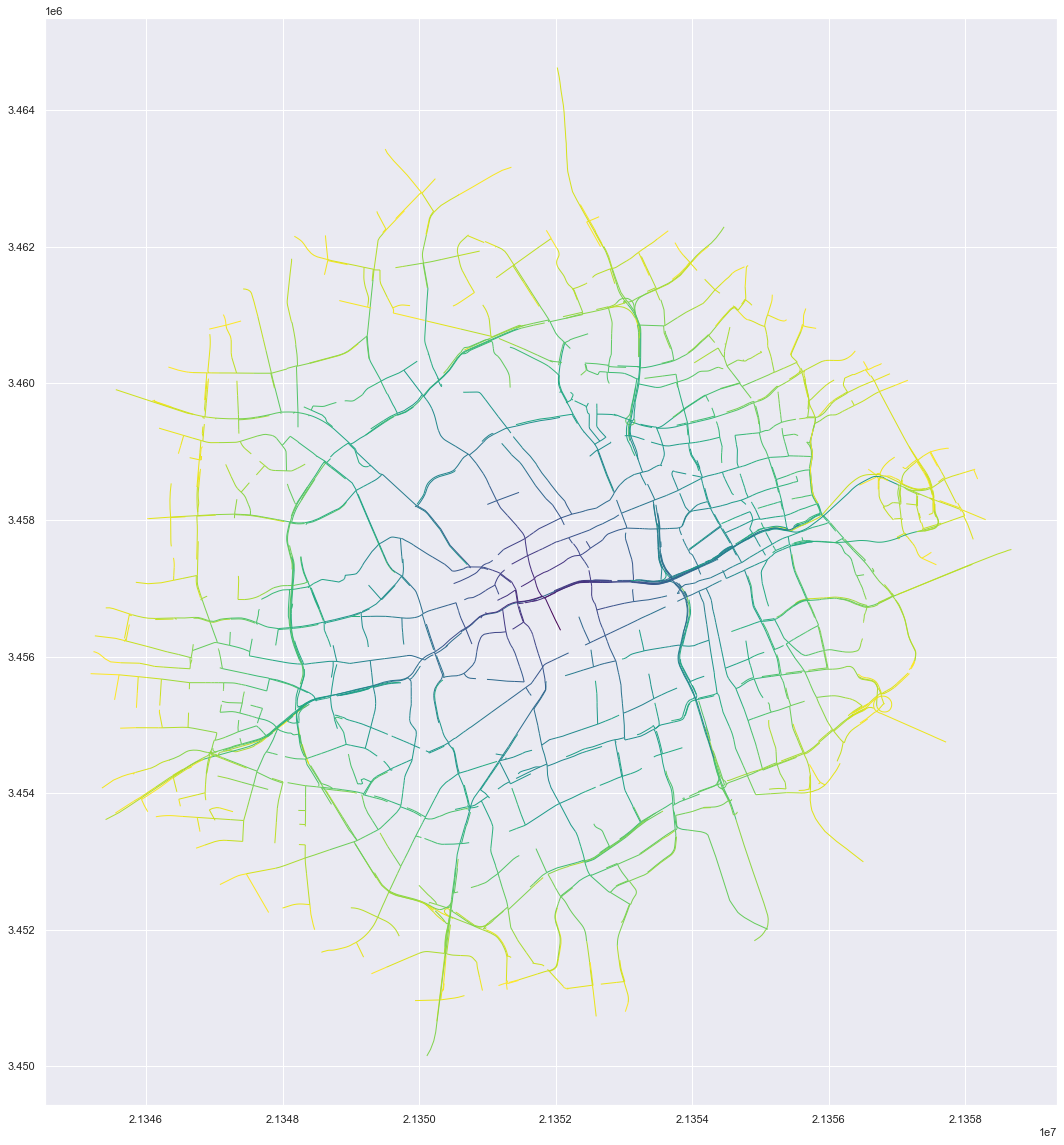

In [316]:
gdf_car[gdf_car.isochrone_u != np.inf].plot(linewidth=1, column='isochrone_u', cmap='viridis', figsize=(20,20))

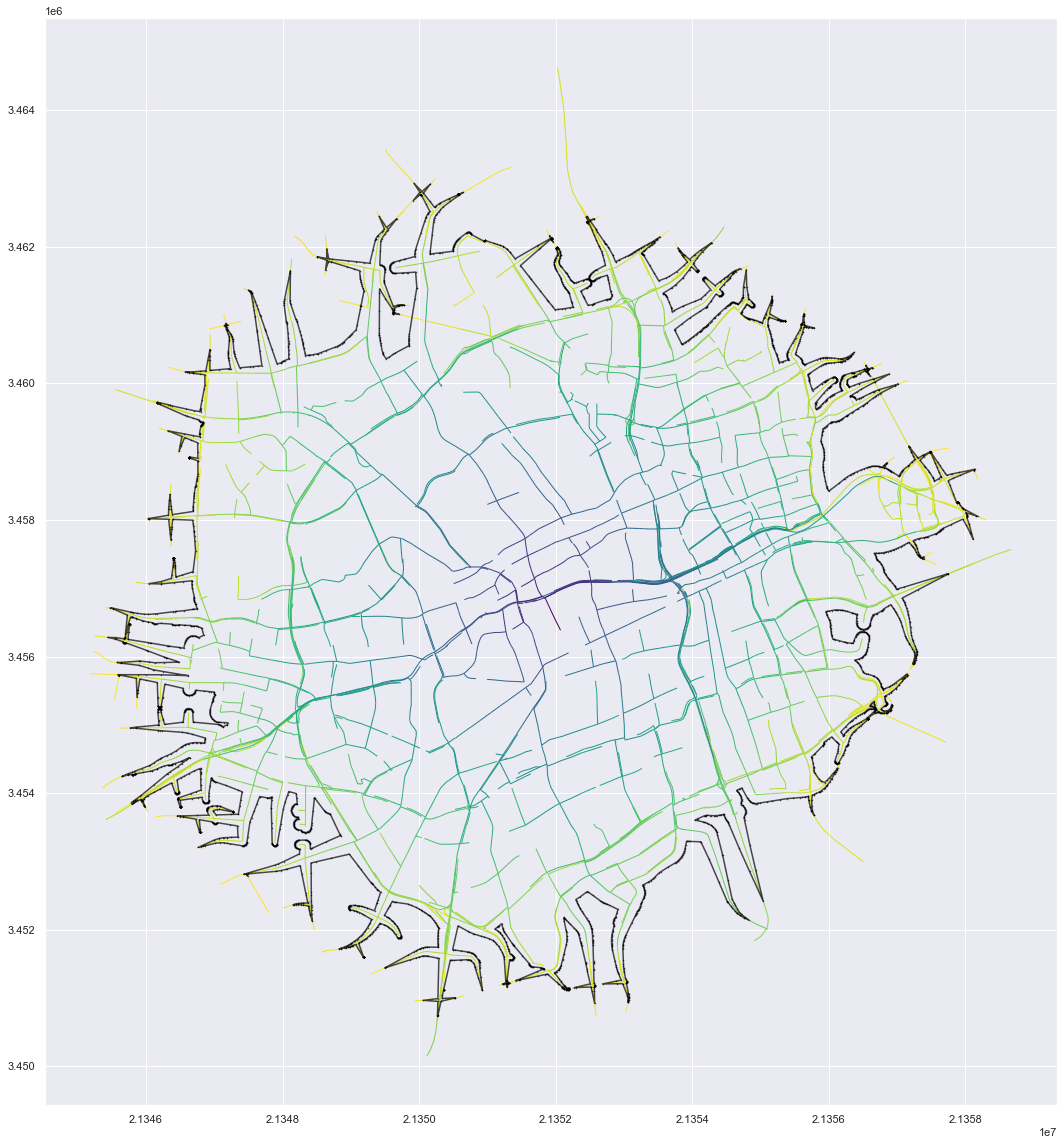

In [366]:
def cut_linestring(line: LineString, distance: float):
    r"""
    # Cuts a line in two at a distance from its starting point

    Returns
    -------
    LineString : dictionary
       Dictionary of n
    """
    if distance <= 0.0 or distance >= line.length:
        return [LineString(line)]
    coords = list(line.coords)
    for i, p in enumerate(coords):
        pd = line.project(Point(p))
        if pd == distance:
            return [
                LineString(coords[:i+1]),
                LineString(coords[i:])]
        if pd > distance:
            cp = line.interpolate(distance)
            return [
                LineString(coords[:i] + [(cp.x, cp.y)]),
                LineString([(cp.x, cp.y)] + coords[i:])]

def asymmetric_segment_buffer(a: Point, b: Point, a_buffer: float, b_buffer: float) -> Polygon:
    r"""
    # create an asymmetic polygon around a segment
    It draws two circles of x_buffer length around a and b then 
    it creates a convex hull around the two circle making a polygon with two 
    round parts. 
    

    Returns
    -------
    Polygon : coordinates of the segment asymmetric buffer polygon
    """
    
    if a_buffer > 0:
        a = a.buffer(a_buffer)
        a = np.ravel(np.array(a.exterior.coords.xy),order='F')
    else:
        a = np.ravel(np.array(a.xy),order='F')
    
    if b_buffer > 0:
        b = b.buffer(b_buffer)
        b = np.ravel(np.array(b.exterior.coords.xy),order='F')
    else:
        b = np.ravel(np.array(b.xy),order='F')
    
    h = np.concatenate((a, b), axis=None)
    h = np.reshape(h, (-1, 2))

    hull = ConvexHull(h)
    xs, ys = h[hull.vertices,0], h[hull.vertices,1]
    return Polygon(zip(xs, ys))


def asymmetric_line_buffer(line: LineString, start_value: float, stop_value: float) -> Polygon:
    if start_value == stop_value:
        return line.buffer(start_value)
    
    coords = list(line.coords)
    dists = [0] + [LineString(line.coords[:i+1]).length for i in range(1,len(coords)-1)] + [line.length]
    buffers = np.interp(dists, [0,line.length], [start_value, stop_value])
    
    polygons = []
    for i in range(len(coords)-1):
        polygons.append(asymmetric_segment_buffer(Point(coords[i]), Point(coords[i+1]), buffers[i], buffers[i+1]))
    return unary_union(polygons)
        
isochrone_polygon = []
speed = 0.8

for i,r in gdf_car[gdf_car.isochrone_u != np.inf].iterrows():
    time_left_u = threshold - r['isochrone_u']
    time_left_v = threshold - r['isochrone_v']
    line_length = r['geometry'].length
    
    if time_left_v < 0:
        stop = time_left_u * line_length / (time_left_u - time_left_v)
        line = cut_linestring(r['geometry'],stop)[0]
        time_left_v = 0
        line_length = line.length
    else:
        line = r['geometry']
    
    isochrone_polygon.append(asymmetric_line_buffer(line, time_left_u * speed, time_left_v * speed))

isochrone_polygon = unary_union(isochrone_polygon)
                            
fig, ax = pyplot.subplots(figsize=(26, 20))
gdf_car[gdf_car.isochrone_u != np.inf].plot(ax=ax,linewidth=1, column='isochrone_u', cmap='viridis', figsize=(15,15))
ax.plot(*isochrone_polygon.exterior.xy, marker='o',color='black',alpha=0.7,markersize=0.5)

In [339]:
ccifc = [['CCIFC', Point(21351908, 3456756)]]
ccifc.append(['CCIFC-foot', Point(21351908, 3456756).buffer(15*60*1.33)])
ccifc.append(['CCIFC-cycle', Point(21351908, 3456756).buffer(15*60*3.05)])
ccifc.append(['CCIFC-car', Point(21351908, 3456756).buffer(15*60*8.33)])




In [340]:
ccifc.append(['CCIFC-car-precise', isochrone_polygon])

In [347]:
ccifc.append(['CCIFC-bike-precise', isochrone_polygon])

In [352]:
ccifc.append(['CCIFC-foot-precise', isochrone_polygon])

In [356]:
ccifc.remove(['CCIFC', Point(21351908, 3456756)])

In [357]:
gpd1 = gpd.GeoDataFrame(ccifc, columns=['Name', 'geometry'])

In [358]:
gpd1 = gpd1.set_crs(4576)

In [359]:
gpd1.to_file('/Users/fabien/Documents/workspace/shanghai-ccifc.shp')

In [363]:
gpd1['area'] = gpd1.geometry.area

In [369]:
gpd1[['Name','area']]   #176 mill ->70 mill   # 23.6 mill -> 13 mill # 4.4 -> 2.6 foot

,Name,area
0,CCIFC-foot,4.494075e+06
1,CCIFC-cycle,2.363397e+07
2,CCIFC-car,1.762897e+08
3,CCIFC-car-precise,7.594111e+07
4,CCIFC-bike-precise,1.324911e+07
5,CCIFC-foot-precise,2.672889e+06


<AxesSubplot:>

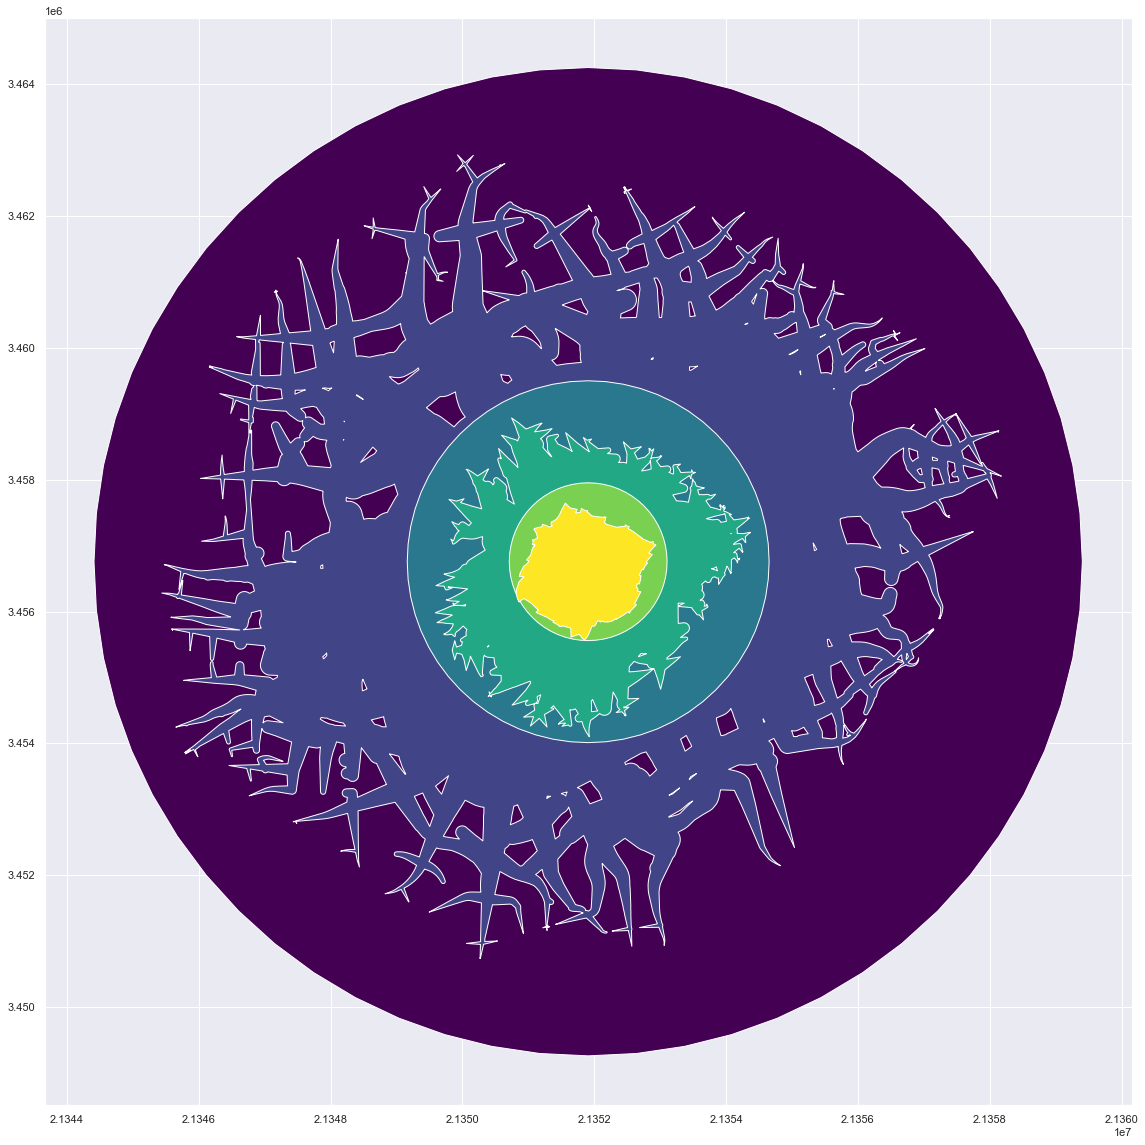

In [365]:
gpd1.sort_values('area',ascending=False).plot(linewidth=1, cmap='viridis', figsize=(26,20))